#Dissimilaridades e métricas


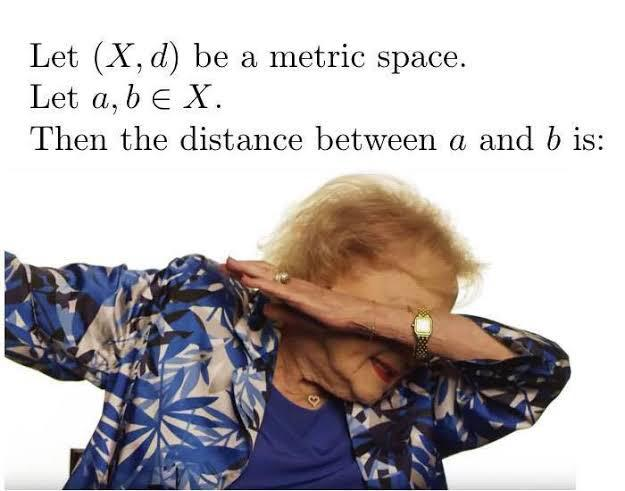

Ainda não consigo acreditar que achei um meme sobre esse tópico... (https://www.reddit.com/r/mathmemes/comments/coe9u4/cant_believe_you_can_make_a_meme_about_metric/)

# Preliminares

Pergunta fundamental e natural em análise de dados:

**Dados dois objetos de interesse, $a$ e $b$, é o caso que $a$ é similar a $b$?**

Apesar de natural, a resposta para a pergunta acima nem sempre é simples e pode depender de vários fatores:
- Tipo de dados (numéricos, categóricos, textos, conjuntos, sequências, séries de tempo...)
- Da aplicação e interpretação desejada
- De requisitos impostos por um algoritmo específico
- ...

**Sugestões?**

#Funções de dissimilaridade

Para quantificar a dissimilaridade entre dois objetos, usamos funções de dissimilaridade.

Hoje veremos algumas dissimilaridades populares e úteis.

## Vetores Reais

Comumente, um conjunto de dados é dado por uma matriz $\mathbf{X}$ como a apresentada abaixo.

$$ \mbox{$n$ objetos}\left\{\begin{array}{c}\;\\\;\\\;\\\;\\\;\end{array}\right.\;\;\overbrace{\left[\begin{array}{ccccc}
\begin{array}{c}x_{11}\\\vdots\\x_{i1}\\\vdots\\x_{n1}\end{array}&
\begin{array}{c}\dots\\\ddots\\\dots\\\ddots\\\dots\end{array}&
\begin{array}{c}x_{1j}\\\vdots\\x_{ij}\\\vdots\\x_{nj}\end{array}&
\begin{array}{c}\dots\\\ddots\\\dots\\\ddots\\\dots\end{array}&
\begin{array}{c}x_{1m}\\\vdots\\x_{im}\\\vdots\\x_{nm}\end{array}
\end{array}\right]}^{\mbox{$m$ atributos}} = \mathbf{X}$$



As linhas de $\mathbf{X}$ podem representar Pessoas, Livros, Filmes... Já as colunas representam as características/atributos (*features*) dos objetos.

Assim, cada objeto/linha pode ser visto como um vetor real $m$-dimensional (i.e., um elemento de $\mathbb{R}^m$).

Dados $\mathbf{x} \in \mathbb{R}^m$ e $\mathbf{y} \in \mathbb{R}^m$, como quantificar a diferença entre $\mathbf{x}$ e $\mathbf{y}$?

### Distância Euclidiana

Uma das formas mais comuns de quantificar a distância entre dois vetores é utilizando a distância Euclidiana, que é baseada na norma $\ell_2$.

Nesse caso, dados $\mathbf{x} \in \mathbb{R}^m$ e $\mathbf{y} \in \mathbb{R}^m$:

$$d(\mathbf{x}, \mathbf{y}) =  \Vert \mathbf{x} - \mathbf{y} \Vert_2  = \sqrt{\sum_{i=1}^m (x_i - y_i)^2}.$$

### Distância de Manhattan

Nome inspirado na distância que deve ser percorrida para se chegar a um destino na ilha de Manhattan.

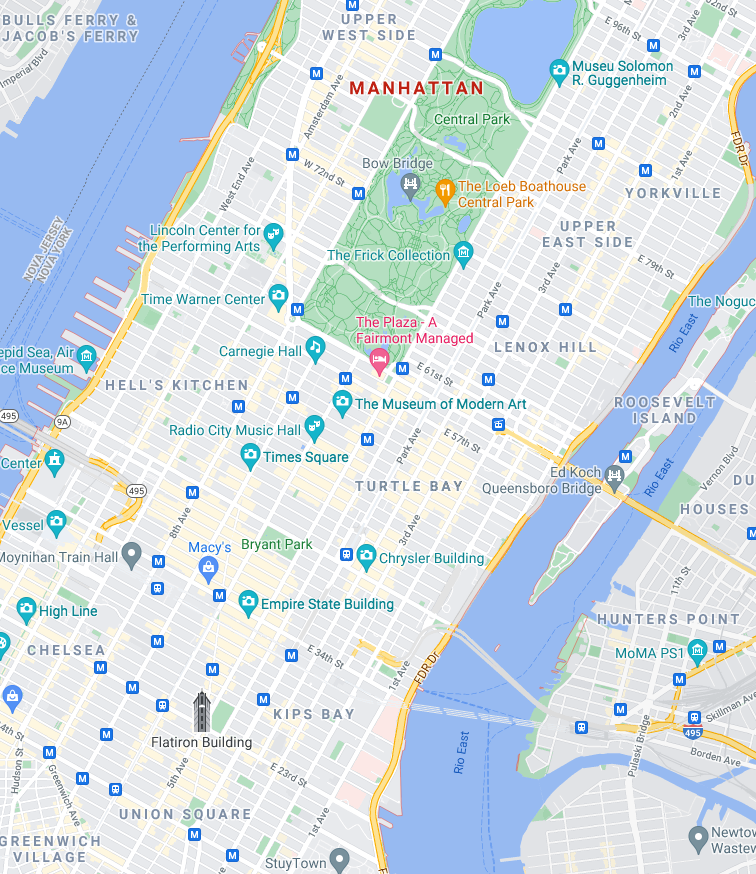

Nesse caso, dados $\mathbf{x} \in \mathbb{R}^m$ e $\mathbf{y} \in \mathbb{R}^m$:

$$d(\mathbf{x}, \mathbf{y}) =  \Vert \mathbf{x} - \mathbf{y} \Vert_1  = {\sum_{i=1}^m |x_i - y_i|}. $$

A figura abaixo apresenta uma interpretação geométrica das duas distâncias no caso do $\mathbb{R}^2$.

In [ ]:
import matplotlib.pyplot as plt

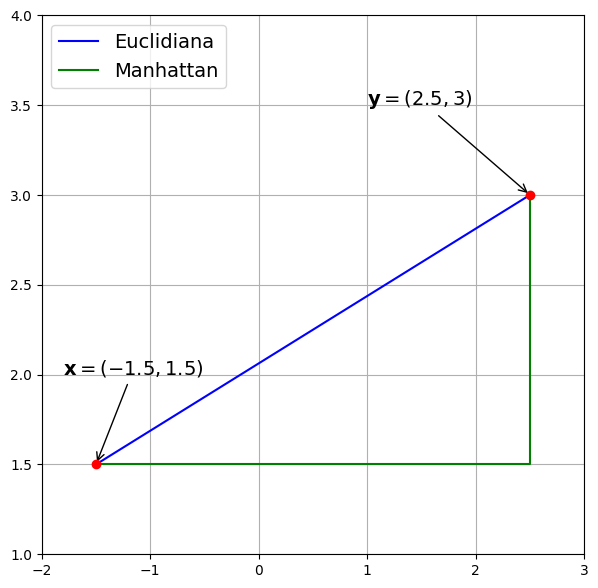

In [ ]:
#@title
plt.figure(figsize=(7,7))

plt.scatter([-1.5, 2.5], [1.5, 3], color = "red", zorder = 5)
plt.annotate(r'$\mathbf{x} = (-1.5, 1.5)$', xy=(-1.5, 1.5), xytext=(-1.8, 2), arrowprops=dict(arrowstyle="->"), size = 14)
plt.annotate(r'$\mathbf{y} = (2.5, 3)$', xy=(2.5, 3), xytext=(1, 3.5), arrowprops=dict(arrowstyle="->"), size = 14)

plt.plot([-1.5, 2.5], [1.5, 3], color = "blue", label = "Euclidiana")
plt.plot([-1.5, 2.5, 2.5], [1.5, 1.5, 3], color = "green", label = "Manhattan")
plt.grid(True)
plt.legend(loc = 2, fontsize = 14)
plt.xlim((-2, 3))
plt.ylim((1, 4));

Com ``numpy``, podemos calcular ambas facilmente:

In [ ]:
import numpy as np

In [ ]:
x = np.array([-1.5, 1.5])
y = np.array([2.5, 3])
print('Distância Euclidiana:', np.linalg.norm(x - y, ord = 2))
print('Distância de Manhattan:', np.linalg.norm(x - y, ord = 1))

Distância Euclidiana: 4.272001872658765
Distância de Manhattan: 5.5


### Distância de *Minkowski*

A Distância de *Minkowski* generaliza os conceitos acima:

$$ d(\mathbf{x}, \mathbf{y}) = \Vert \mathbf{x} - \mathbf{y} \Vert_p = \left(\sum_{i=1}^m |x_i - y_i|^p\right)^{\frac{1}{p}} $$

A figura abaixo apresenta os círculos unitários de acordo com diferentes valores de $p$ (fonte: https://en.wikipedia.org/wiki/Minkowski_distance)

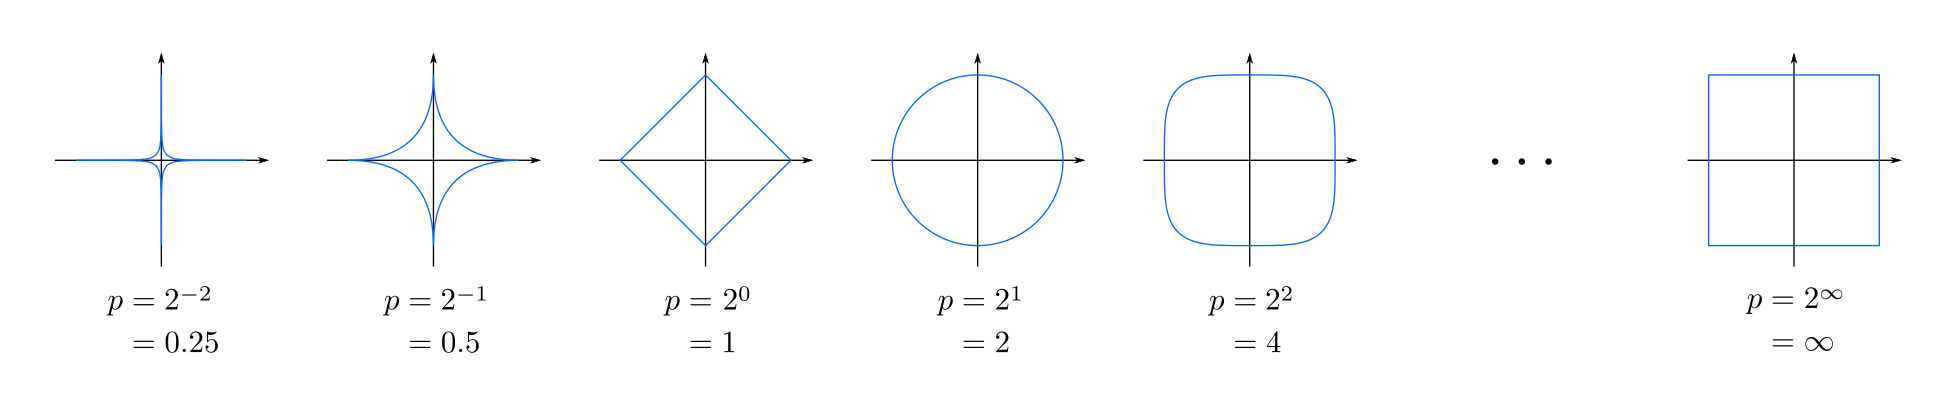

Os seguintes casos especiais são interessantes:
* $p = 1$, tem-se a distância de *Manhattan*
* $p = 2$, tem-se a distância Euclidiana
* $\displaystyle\lim _{p\to \infty }{\left(\sum _{i=1}^{m}|x_{i}-y_{i}|^{p}\right)^{\frac {1}{p}}}=\max _{i=1}^{m}|x_{i}-y_{i}|$
* $\displaystyle\lim _{p\to -\infty }{\left(\sum _{i=1}^{m}|x_{i}-y_{i}|^{p}\right)^{\frac {1}{p}}}=\min _{i=1}^{m}|x_{i}-y_{i}|$

### Distância do Cosseno

Da Álgebra Linear, sabemos que o cosseno do ângulo entre dois vetores $\mathbf{x} \in \mathbb{R}^m$ e $\mathbf{y} \in \mathbb{R}^m$ é:

$$\cos(\mathbf{x}, \mathbf{y}) = \frac{ \mathbf{x} \cdot \mathbf{y} }{\Vert\mathbf{x}\Vert \Vert\mathbf{y}\Vert} = \frac{\sum_{i = 1}^mx_iy_i}{\sqrt{\sum_{i = 1}^mx_i^2}\sqrt{\sum_{i = 1}^my_i^2}}$$




Vejamos alguns exemplos:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
x = np.array([-0.5, -1])
y = np.array([1, 2])
z = np.array([1, -0.5])
w = np.array([1, 1])
v = np.array([0.5, 1])

In [ ]:
def plot_vector(v, color):
  plt.quiver([0], [0], v[0], v[1],
       color = color,
       zorder = 10, alpha = 0.5, width = 0.013, angles='xy', scale_units='xy', scale=1)

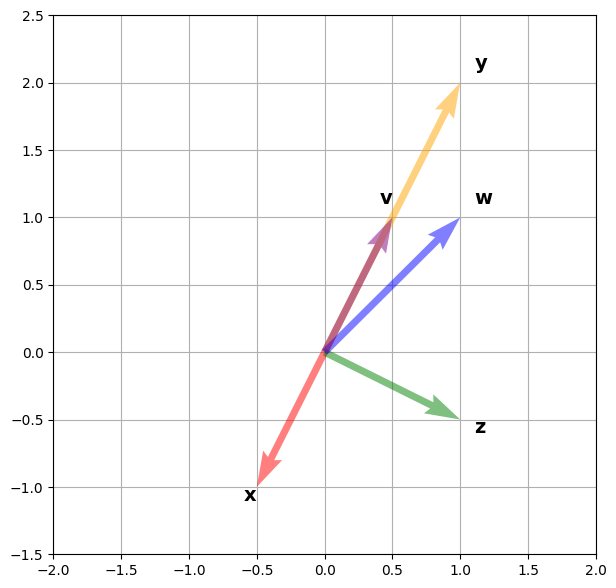

In [ ]:
plt.figure(figsize = (7, 7))

plot_vector(x, "red")
plot_vector(y, "orange")
plot_vector(z, "green")
plot_vector(w, "blue")
plot_vector(v, "purple")

plt.annotate(r'$\mathbf{v}$', xy=v, xytext=v+[-0.1, 0.1], size = 14)
plt.annotate(r'$\mathbf{x}$', xy=x, xytext=x-0.1, size = 14)
plt.annotate(r'$\mathbf{y}$', xy=y, xytext=y+0.1, size = 14)
plt.annotate(r'$\mathbf{z}$', xy=z, xytext=z+[0.1, -0.1], size = 14)
plt.annotate(r'$\mathbf{w}$', xy=z, xytext=w+[0.1, 0.1], size = 14)

plt.grid(True)

plt.xlim((-2, 2))
plt.ylim((-1.5, 2.5));

In [ ]:
def cosine(v, w):
  return v.dot(w) / (np.linalg.norm(v, ord = 2) * np.linalg.norm(w, ord = 2))

In [ ]:
print('cos(w, y) = ', cosine(w, y))
print('cos(x, y) = ', cosine(x, y))
print('cos(z, y) = ', cosine(z, y))
print('cos(v, y) = ', cosine(v, y))

cos(w, y) =  0.9486832980505138
cos(x, y) =  -0.9999999999999998
cos(z, y) =  0.0
cos(v, y) =  0.9999999999999998


Assim, uma forma popular de computar a distância entre vetores $\mathbf{x}$ e $\mathbf{y}$ é utilizando a distância do cosseno:

$$d(\mathbf{x}, \mathbf{y}) = 1 - \cos(\mathbf{x}, \mathbf{y}).$$

Repare que se as componentes de $\mathbf{x}$ e $\mathbf{y}$ forem não negativas, então $0 \le d(\mathbf{x}, \mathbf{y}) \le 1$.

**Como comparar a distância do cosseno com a distância euclidiana?**

São ferramentas diferentes e podem gerar resultados completamente diferentes. Algumas observações importantes:
- A distância do cosseno assume valores no intervalo $[0, 2]$, enquanto a distância euclidiana assume valores em $[0, \infty)$
- Pontos distantes com respeito à distância euclidiana podem estar próximos de acordo com o distância do cosseno.

Do ponto de vista de análise textual (aula passada), essas observações fazem com que a distância do cosseno seja interessante para comparar documentos:
1. Documentos sobre os mesmos tópicos, mas com intensidades diferentes, serão similares
2. As distâncias são menos influenciadas pelo comprimento dos documentos e pela diferença dos comprimentos dos documentos

## Vetores de bits

Quando trabalhamos com vetores de bits, a distância de Manhattan é comumente utilizada. Neste caso especial, ela é chamada de distância de *Hamming*.

Sejam $\mathbf{x} \in \{0, 1\}^m$ e $\mathbf{y} \in \{0, 1\}^m$, então a distância de *Hamming* é definida por:

$$d(\mathbf{x}, \mathbf{y}) = \sum_{i = 1}^m|x_i - y_i|.$$

A distância de *Hamming* conta o menor número de *bit flips* que são necessários para transformar um dos vetores no outro.

## Conjuntos

Sejam $X$ e $Y$ dois conjuntos, sendo que não há restrições sobre os tipos dos elementos que tais conjuntos contêm.

A distância de *Jaccard* permite quantificar a diferença entre $X$ e $Y$. Tem-se:
$$d(X, Y) = 1 - \frac{|X\cap Y|}{|X\cup Y|}.$$

Se $X \approx Y$, então $X\cap Y \approx X\cup Y$. Assim $d(X, Y) \approx 0$.
Similarmente, se $X$ e $Y$ são muito distintos, $d(X, Y) \approx 1$.

Uma implementação simples em Python.

In [ ]:
def jaccard_distance(x, y):
  inter = len(x.intersection(y))
  union = len(x) + len(y) - inter
  if union == 0:
    return 0
  else:
    return 1 - inter / union

In [ ]:
X = set(['carro', '1', '2.0', 'A'])
Y = set(['1', 'A', 'carro', '3.0'])

print('d(X, Y) = ', jaccard_distance(X, Y))

d(X, Y) =  0.4


Conjuntos podem ser representados por vetores de bits. No caso do exemplo acima, temos:

In [ ]:
import pandas as pd

In [ ]:
df = pd.DataFrame([[1, 1, 1, 1, 0], [1, 1, 0, 1, 1]], columns = 'carro 1 2.0 A 3.0'.split(), index = ['X', 'Y'])
df

,carro,1,2.0,A,3.0
X,1,1,1,1,0
Y,1,1,0,1,1


Seja $\mathbf{x}$ a representação em vetor de bits de $X$ e $\mathbf{y}$ a representação em vetor de bits de $Y$. Assim, é possível escrever a distância de *Jaccard* como:
$$d(X, Y) = 1 - \frac{\sum_{i = 1}^m\min\{x_i, y_i\}}{\sum_{i = 1}^m\max\{x_i, y_i\}},$$
onde $m = |X \cup Y|$.

Agora repare que a expressão acima, pode ser computada mesmo nos casos em que $\mathbf{x}$ e $\mathbf{y}$ são vetores de números reais.
Assim, considere que $\mathbf{x} \in \mathbb{R}^m$ e $\mathbf{y} \in \mathbb{R}^m$, a quantidade
$$1 - \frac{\sum_{i = 1}^m\min\{x_i, y_i\}}{\sum_{i = 1}^m\max\{x_i, y_i\}}$$
é conhecida como **distância generalizada de *Jaccard***.


## Sequências

Sejam $S_1 = a_1, a_2, \dots, a_n$ e $S_2 = b_1, b_2, \dots, b_m$ duas sequências, onde todos os $a_i$'s e $b_i$'s pertencem a um alfabeto $\Sigma$.

Exemplo:
* $S_1 = $ ``waiter``,
* $S_2 = $ ``water`` e
* $\Sigma = $ alfabeto de letras minúsculas.

Como quantificar a dissimilaridade entre $S_1$ e $S_2$?

Para essa tarefa, pode-se usar a **distância de edição** (ou *Levenshtein distance*). A ideia é computar a soma mínima dos custos de todas as operações necessárias para transforma $S_1$ em $S_2$.

Definição e algoritmo vide **Lista 2**.

## Séries Temporais

Considere agora que estejamos trabalhando com observações coletadas ao longo do tempo. Considere também que os intervalos de medição são fixos, ou seja, nossos objetos de interesse são séries temporais.

Considere o exemplo abaixo. As duas séries são similares? Por quê?

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

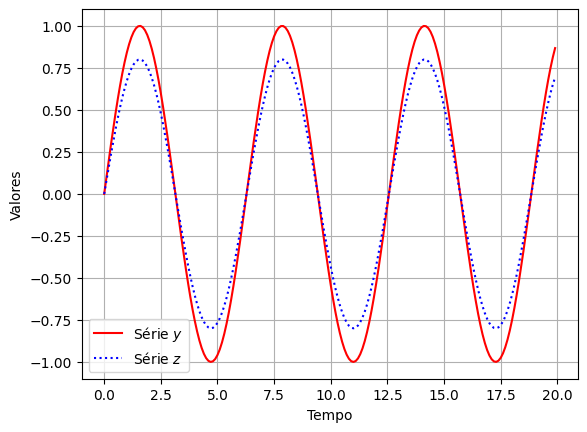

In [ ]:
x = np.arange(0, 20, 0.1);
y = np.sin(x)
z = 0.8 * np.sin(x)

plt.plot(x, y, color = "red", markersize = 2, label = 'Série $y$')
plt.plot(x, z, linestyle = ':', color = "blue", markersize = 2, label = 'Série $z$')

plt.xlabel('Tempo')
plt.ylabel('Valores')
plt.legend(loc = 'best')
plt.grid(True)

Mas e agora?

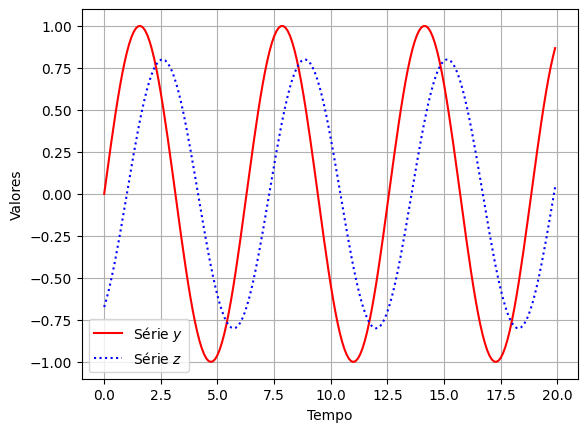

In [ ]:
x = np.arange(0, 20, 0.1);
y = np.sin(x)
z = 0.8 * np.sin(x - 1)

plt.plot(x, y, color = "red", markersize = 2, label = 'Série $y$')
plt.plot(x, z, linestyle = ':', color = "blue", markersize = 2, label = 'Série $z$')

plt.xlabel('Tempo')
plt.ylabel('Valores')
plt.legend(loc = 'best')
plt.grid(True)

No primeiro caso, podemos usar, por exemplo, a distância euclidiana, tratando cada série como um vetor.

Já no segundo caso, se usarmos a distância euclidiana, receberemos um resultado que indica que as séries são bem diferentes. No entanto, se a série azul for deslocada para a esquerda, pode-se perceber que ela descreverá, basicamente, o mesmo fenômeno que a série vermelha.

Assim, distâncias que comparam vetores **indice a índice não são adequadas para o caso de séries temporais** (a não ser que você queira fazer a comparação dessa forma).

Para fazer esse tipo de comparação, utilizamos uma dissimilaridade conhecida como DTW (*Dynamic Time Warping*). A Figura abaixo ilustra o conceito:

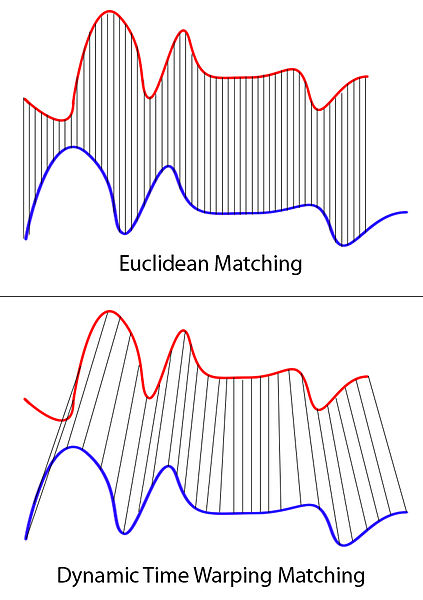

(fonte da figura: https://commons.wikimedia.org/wiki/File:Euclidean_vs_DTW.jpg)

Propriedades e algoritmo vide **Lista 2**.

## Matrizes

Sejam $\mathbf{X}$ e $\mathbf{Y}$ matrizes pertencentes ao $\mathbb{R}^{m\times n}$ (ou seja, matrizes reais com $m$ linhas e $n$ colunas).

Uma forma padrão de comparar $\mathbf{X}$ e $\mathbf{Y}$ é utilizando a norma de *Frobenius*. Ou seja:
$$d(\mathbf{X}, \mathbf{Y}) = \Vert \mathbf{X} - \mathbf{Y} \Vert_F = \sqrt{\sum_{i = 1}^m\sum_{j = 1}^n(x_{ij} - y_{ij})^2}.$$

In [ ]:
import numpy as np

In [ ]:
X = np.array([[1,2,3],[4,5,6],[7,8,9]])
Y = X + 0.001

print('X = \n', X)
print('Y = \n', Y)
print('d(X, Y) = ', np.linalg.norm(X - Y, ord = 'fro'))

X = 
 [[1 2 3]
 [4 5 6]
 [7 8 9]]
Y = 
 [[1.001 2.001 3.001]
 [4.001 5.001 6.001]
 [7.001 8.001 9.001]]
d(X, Y) =  0.002999999999999966


# Métricas

Algumas funções de dissimilaridade satisfazem as seguintes propriedades:
1. $d(x, y) \ge 0$
2. $d(x, y) = 0 \iff x = y$
3. $d(x, y) = d(y, x)$
4. $d(x, y) \le d(x, z) + d(z, y)$.

As dissimilaridades que satisfazem essas propriedades são chamadas de **métricas**.

Por que o conceito de métrica é relevante?
- Alguns algoritmos só funcionam quando as dissimilaridades são computadas por métricas
- O uso de dissimilaridades que são métricas simplifica muitas provas
- Métricas facilitam a interpretação de alguns resultados (apesar de esta ser uma afirmação perigosa, vide aula que vem).


### Como provar que uma dissimilaridade é uma métrica?

Vamos exemplicar uma prova com a distância de *Hamming*. Lembrando que a distância de *Hamming* é o número de posições em que $\mathbf{x}$ e $\mathbf{y}$ diferem.

#### Não negatividade

O número de posições que dois vetores diferem nunca será um número negativo.

#### Identidade de indiscerníveis

Se $d(\mathbf{x}, \mathbf{y}) = 0$, então não é necessário inverter nenhum bit de $\mathbf{x}$ para obter $\mathbf{y}$. Logo, os dois vetores são iguais.
Reciprocamente, se $\mathbf{x} = \mathbf{y}$, então $d(\mathbf{x}, \mathbf{y}) = 0$.

#### Simetria

O número de posições em que $\mathbf{x}$ e $\mathbf{y}$ diferem é o mesmo que o número de posições que $\mathbf{y}$ e $\mathbf{x}$ diferem.

#### Desigualdade triangular

Suponha que existam $\mathbf{x}$, $\mathbf{y}$ e $\mathbf{w}$ tais que
$$d(\mathbf{x}, \mathbf{y}) > d(\mathbf{x}, \mathbf{w}) + d(\mathbf{w}, \mathbf{y}).$$

Mas veja que podemos transformar $\mathbf{x}$ em $\mathbf{w}$ com $d(\mathbf{x}, \mathbf{w})$ inversões de bits e podemos transformar $\mathbf{w}$ em $\mathbf{y}$ com $d(\mathbf{w}, \mathbf{y})$ inversões de bits. Combinando esses dois passos, podemos transformar $\mathbf{x}$ em $\mathbf{y}$ com $d(\mathbf{x}, \mathbf{w}) + d(\mathbf{w}, \mathbf{y})$ inversões de bits.
**Mas isso contradiz a inequação colocada como hipótese.**

Assim, deve ser o caso que
$$d(\mathbf{x}, \mathbf{y}) \le d(\mathbf{x}, \mathbf{w}) + d(\mathbf{w}, \mathbf{y}).$$

# Exemplo: O problema da busca por objetos similares

Para abordar problemas corretamente e escolher os algoritmos certos, cientistas de dados precisam se preocupar com a escolha da métrica (ou dissimilaridade) constantemente. Vamos considerar um problema simples.

Seja $X = \{\mathbf{x}_1, \mathbf{x}_2, \dots, \mathbf{x}_n\}$ uma coleção de objetos, com $\mathbf{x}_i\in\mathbb{R}^m$, e $d$ uma função de dissimilaridade.

Dada uma *query* $\mathbf{q} \in \mathbb{R}^m$, quais pontos em $X$ estão "próximos" de $\mathbf{q}$?

**Sugestões?**

## Estratégia 1

Realize uma busca exaustiva. Assumindo que a função de dissimilaridade possa ser computada em tempo $O(m)$, cada *query* pode ser realizada em $O(nm)$.

**Caro!**

## Estratégia 2

Se $m << n$, o problema pode ser resolvido de forma eficiente utilizando uma *KD-Tree* (https://en.wikipedia.org/wiki/K-d_tree) ou variações.

Recomendo o estudo, mas não entraremos nesse tópico nessa disciplina.

## Estratégia 3 - *Locality Sensitive Hashing*

Se a dimensionalidade do problema é alta (i.e., $m$ é grande), podemos fazer uso de abordagens não exatas. Por exemplo, podemos utilizar funções *hash* de similaridade ou LSH (*Locality Sensitive Hashing*).

Vamos abordar o conceito de maneira informal. O texto da Wikipédia (https://en.wikipedia.org/wiki/Locality-sensitive_hashing) e o livro *Mining of Massive Datasets* (Referência no AVA) trazem um formalismo mais adequado.

**Ideia geral:** "encontrar/obter" uma função *hash*, $h$, tal que:
* Se $d(\mathbf{x}, \mathbf{y})$ assumir valor pequeno, então a $P(h(\mathbf{x}) = h(\mathbf{y}))$ é alta.
* Se $d(\mathbf{x}, \mathbf{y})$ assumir valor grande, então a $P(h(\mathbf{x}) = h(\mathbf{y}))$ é pequena.

#### Como podemos usar LSH para resolver o problema de encontrar pontos similares a $\mathbf{q}$ em $X$?

Sugestão:
1. pré-compute $h(\mathbf{x})$, para todo $\mathbf{x} \in X$
2. dada uma *query* $\mathbf{q}$, compute $h(\mathbf{q})$
3. inspecione todos os elementos em $X$ que colidem com $\mathbf{q}$
4. retorne apenas os pontos que de fato forem similares.

#### Exemplo de LSH para a distância de *Hamming*

**Pré-processamento:** obtenha um número aleatório, $i$, do conjunto $\{1, 2, \dots, m\}$ e defina $h(\mathbf{x}) = x_i$.




Dados vetores de bits $\mathbf{x}$ e $\mathbf{y}$ de comprimento $m$ quaisquer, qual a probabilidade de colisão com $h$?

Tem-se:

$$P(h(\mathbf{x}) = h(\mathbf{y})) = \frac{m - d(\mathbf{x}, \mathbf{y})}{m}.$$

Assim, essa definição captura a intuição de uma função *hash* para que ela possa ser uma LSH.

Veja que essa construção não resolve o problema mencionado acima. Como podemos melhorar essa LSH para que ela seja útil do ponto de vista prático?

### Exemplo de LSH para a distância de Jaccard

Não veremos a definição e a implementação nessa disciplina (fora do escopo para uma aula), mas vamos ver uma aplicação de uma função hash de similaridade muito útil no processamento de texto. Essa função, comumente denotada por *MinHash* é tal que, dados dois conjuntos $X$ e $Y$:
$$P(MinHash(X) \neq MinHash(Y)) = 1 - \frac{|X\cap Y|}{|X \cup Y|}.$$
Em outras palavras, a probabilidade de os hashes de dois conjuntos não colidirem é exatamente a distância de Jaccard entre os dois conjuntos.

Ou, podemos ainda dizer que a probabilidade dos hashes colidirem é a *similaridade* de Jaccard dos dois conjuntos.



Quem quiser aprender mais sobre a construção dessa função de hash pode ler o Capítulo 3 do Livro [*Mining with Massive Datasets*](http://www.mmds.org/) ou [esse artigo](https://cs.brown.edu/courses/cs253/papers/nearduplicate.pdf).

In [ ]:
!pip install datasketch unidecode

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.2/89.2 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 10.6 MB/s eta 0:00:00


Veja abaixo um exemplo de como essa função de hash pode ser utilizada para aproximar a similaridade de Jaccard.

In [ ]:
from datasketch import MinHash, MinHashLSH

data1 = ['minhash', 'is', 'a', 'probabilistic', 'data', 'structure', 'for',
        'estimating', 'the', 'similarity', 'between', 'datasets']
data2 = ['minhash', 'is', 'a', 'probability', 'data', 'structure', 'for',
        'estimating', 'the', 'similarity', 'between', 'documents']

m1, m2 = MinHash(), MinHash()
for d in data1:
    m1.update(d.encode('utf8'))
for d in data2:
    m2.update(d.encode('utf8'))
print("Estimated Jaccard for data1 and data2 is", m1.jaccard(m2))

s1 = set(data1)
s2 = set(data2)
actual_jaccard = float(len(s1.intersection(s2)))/float(len(s1.union(s2)))
print("Actual Jaccard for data1 and data2 is", actual_jaccard)

Estimated Jaccard for data1 and data2 is 0.7109375
Actual Jaccard for data1 and data2 is 0.7142857142857143


Vamos exemplificar a utilidade dessa função mostrando como ela pode ser utilizada para encontrar documentos (quase) duplicados em grandes bases de dados.

In [ ]:
from sklearn.datasets import fetch_20newsgroups

news, _ = fetch_20newsgroups(
    shuffle=True,
    random_state=1,
    remove=("headers", "footers", "quotes"),
    return_X_y=True,
)

In [ ]:
len(news)

11314

O Código abaixo contém apenas funcionalidades básicas para limpeza de textos (Aulas Passadas).

In [ ]:
import nltk
import unidecode
import string
nltk.download('punkt_tab')
from nltk import word_tokenize

def clean_text(text):
  table = str.maketrans('', '', string.punctuation)
  tokens = word_tokenize(text)
  tokens = [w.translate(table) for w in tokens]
  tokens = [w.lower() for w in tokens]
  tokens = [unidecode.unidecode(w) for w in tokens]
  tokens = [w for w in tokens if w.isalpha()]
  return tokens

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
news[0]

"Well i'm not sure about the story nad it did seem biased. What\nI disagree with is your statement that the U.S. Media is out to\nruin Israels reputation. That is rediculous. The U.S. media is\nthe most pro-israeli media in the world. Having lived in Europe\nI realize that incidences such as the one described in the\nletter have occured. The U.S. media as a whole seem to try to\nignore them. The U.S. is subsidizing Israels existance and the\nEuropeans are not (at least not to the same degree). So I think\nthat might be a reason they report more clearly on the\natrocities.\n\tWhat is a shame is that in Austria, daily reports of\nthe inhuman acts commited by Israeli soldiers and the blessing\nreceived from the Government makes some of the Holocaust guilt\ngo away. After all, look how the Jews are treating other races\nwhen they got power. It is unfortunate.\n"

In [ ]:
print(clean_text(news[0]))

['well', 'i', 'm', 'not', 'sure', 'about', 'the', 'story', 'nad', 'it', 'did', 'seem', 'biased', 'what', 'i', 'disagree', 'with', 'is', 'your', 'statement', 'that', 'the', 'us', 'media', 'is', 'out', 'to', 'ruin', 'israels', 'reputation', 'that', 'is', 'rediculous', 'the', 'us', 'media', 'is', 'the', 'most', 'proisraeli', 'media', 'in', 'the', 'world', 'having', 'lived', 'in', 'europe', 'i', 'realize', 'that', 'incidences', 'such', 'as', 'the', 'one', 'described', 'in', 'the', 'letter', 'have', 'occured', 'the', 'us', 'media', 'as', 'a', 'whole', 'seem', 'to', 'try', 'to', 'ignore', 'them', 'the', 'us', 'is', 'subsidizing', 'israels', 'existance', 'and', 'the', 'europeans', 'are', 'not', 'at', 'least', 'not', 'to', 'the', 'same', 'degree', 'so', 'i', 'think', 'that', 'might', 'be', 'a', 'reason', 'they', 'report', 'more', 'clearly', 'on', 'the', 'atrocities', 'what', 'is', 'a', 'shame', 'is', 'that', 'in', 'austria', 'daily', 'reports', 'of', 'the', 'inhuman', 'acts', 'commited', 'by',

Vamos agora computar os hashes de cada uma das notícias da base de dados.

In [ ]:
# essa célula demora mais ou menos 1 minuto no Google Colab
hashes = []

for n in news:
  tokens = clean_text(n)
  h = MinHash()
  for token in tokens:
    h.update(token.encode('utf8'))
  hashes.append(h)

Agora, vamos utilizar os valores da biblioteca para criar um índice, onde conjuntos similares serão colocados em um mesmo grupo.

In [ ]:
lsh = MinHashLSH(threshold = 0.5, num_perm = 128) # similaridade de ao menos 50%
with lsh.insertion_session() as session:
    for i, m in enumerate(hashes):
        session.insert(i, m)

Para exemplificar, vamos fazer uma conjunta com um pedaço de uma notícia.

In [ ]:
len(news[42])

1484

In [ ]:
target = clean_text(news[42][:1000]) # calculando o hash da notícia 42, mas só de um pedaço dela.
q = MinHash()
for token in target:
  q.update(token.encode('utf-8'))

In [ ]:
results = lsh.query(q) # fazendo a busca

In [ ]:
results

[42]

# Exemplo: Pré-processamento - A importância da Padronização e/ou Reescala

Muitos algoritmos de aprendizado de máquina assumem que os dados de entrada estão organizados de uma maneira específica.
Por exemplo, para alguns algoritmos é importante que a média de cada coluna da matriz de dados seja zero. Para outros, é importante que as diferentes características do conjunto de dados estejam na mesma ordem de grandeza.

Dependendo de como os dados foram coletados e armazenados, este pode não ser o caso. Para resolver esse "problema", podemos utilizar a biblioteca ``scikit-learn`` para **padronizar** ou **reescalar** os dados.

Vamos ilustrar o que esses conceitos significam e como podem ser empregados por meio de um exemplo prático utilizando o dataset ``wine`` da biblioteca.

In [ ]:
#@title
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn import datasets
import seaborn as sns
sns.set()

Na primeira parte do conjunto de dados, a matriz $\mathbf{X}$ contém várias amostras de vinhos, cada uma em uma representada em uma linha da matriz. Cada uma das 13 colunas de $\mathbf{X}$ representa uma **característica** dos vinhos analisados.

Além disso, cada amostra está relacionada a um tipo de vinho específico. Nesse conjunto de dados, há três tipos de vinhos, os quais estão representados em $\mathbf{y}$.

In [ ]:
wine = datasets.load_wine(return_X_y = False, as_frame = True)
X = wine.data
y = wine.target.values
X.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


Observe que cada coluna da matriz de dados acima representa uma característica de uma amostra de vinho. Assim, cada coluna pode assumir valores em intervalos muito distintos das demais devido a:
1. Natureza ou concentração da característica medida; ou
2. Unidades de medidas utilizadas.

Vamos considerar as colunas ``nonflavanoid_phenols`` e ``proline`` como exemplos. Vejamos seus respectivos histogramas.

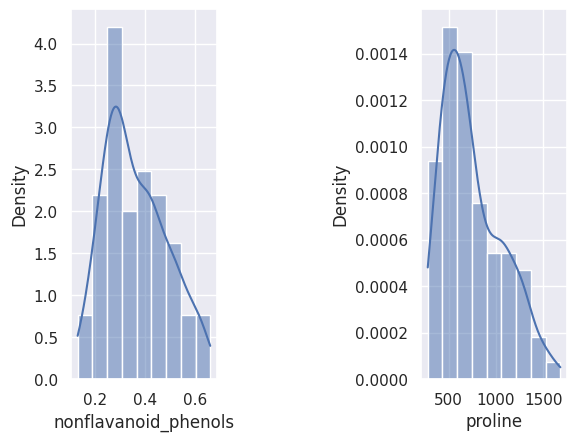

In [ ]:
#@title
plt.subplot(1, 3, 1)
sns.histplot(data = X, x = 'nonflavanoid_phenols', kde = True, stat = 'density');
plt.subplot(1, 3, 3)
sns.histplot(data = X, x = 'proline', kde = True, stat = 'density');

A coluna ``nonflavonoid_phenols`` assume valores pequenos, geralmente, menores que 1. Já a coluna ``proline`` assume valores muito grandes, geralmente de algumas centenas.

**Por que isso é relevante?**

Muitos algoritmos de aprendizado de máquina são baseados nas **distâncias** entre objetos do conjunto de dados.
Se colunas diferentes possuírem valores de ordens de grandeza muito diferentes (como no exemplo acima), isso pode prejudicar o desempenho de alguns algoritmos.

## Calculando a distância entre todos os objetos

Vamos computar a distância euclidiana **entre todos os pares de amostras** de vinho do conjunto ``wine``. Após isso, vamos observar a distribuição dos valores dessas distâncias por meio de um histograma.

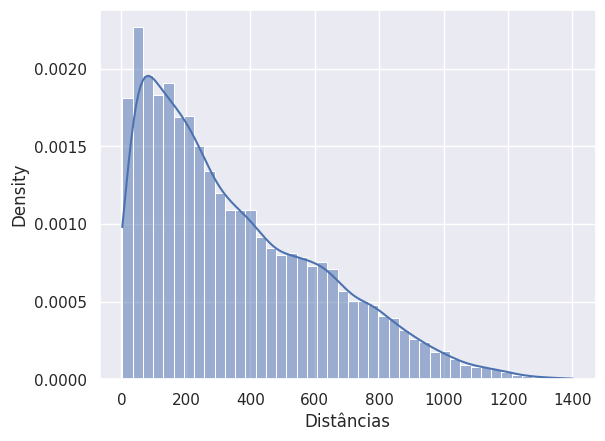

In [ ]:
import numpy as np
from scipy.spatial.distance import pdist

distances = pdist(X, 'euclidean')
ax = sns.histplot(data = distances, stat = "density", kde = True);
ax.set(xlabel = 'Distâncias');

Pelo gráfio acima, pode-se perceber que, em geral, os valores das distâncias entre as amostras de vinho são relativamente altos.

Isso faz com que variações nas características com valores em intervalos menores (e.g., ``nonflavanoid_phenols`` e ``hue``) contribuam menos com as distâncias, mesmo que tais variações sejam significativas.

Esse fenômeno pode interferir no bom funcionamento de alguns algoritmos que veremos nas próximas aulas.

Para evitar problemas relacionados a características com diferentes ordens de grandeza, os dados devem ser transformados. A seguir, discutiremos duas alternativas.


### Padronização

A Padronização consiste em:
1. Centralizar cada coluna da matriz de dados, para que tenha média zero;
2. Dividir cada coluna da matriz de dados por um valor, para que tenha desvio padrão 1.

Na ``scikit-learn``, isso pode ser feito com a classe [``StandardScaler``](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler).

Vejamos um exemplo com o conjunto de dados ``wine``.

In [ ]:
from sklearn import preprocessing

# construindo o scaler para os dados
# with_mean: indica que os dados transformados terão média zero
# with_std: indica que os dados transformados terão desvio padrão 1
scaler = preprocessing.StandardScaler(with_mean = True, with_std = True)

# obtendo os parâmetros do scaler a partir do conjunto de dados
scaler.fit(X)

# transformando um conjunto de dados com o scaler obtido
X_scaled = scaler.transform(X)

# transformando os dados em pandas DataFrame
X_scaled = pd.DataFrame(X_scaled, index = X.index, columns = X.columns)
X_scaled

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,0.876275,2.974543,0.305159,0.301803,-0.332922,-0.985614,-1.424900,1.274310,-0.930179,1.142811,-1.392758,-1.231206,-0.021952
174,0.493343,1.412609,0.414820,1.052516,0.158572,-0.793334,-1.284344,0.549108,-0.316950,0.969783,-1.129518,-1.485445,0.009893
175,0.332758,1.744744,-0.389355,0.151661,1.422412,-1.129824,-1.344582,0.549108,-0.422075,2.224236,-1.612125,-1.485445,0.280575
176,0.209232,0.227694,0.012732,0.151661,1.422412,-1.033684,-1.354622,1.354888,-0.229346,1.834923,-1.568252,-1.400699,0.296498


Veja que agora, todas as colunas da matriz possuem a mesma ordem de grandeza.

Isso pode ser confirmado observando estatísticas descritivas dos dados antes e após a padronização.

Antes da padronização.

In [ ]:
X.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


Após a padronização.

In [ ]:
X_scaled.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,178.000000,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02
mean,-8.382808e-16,-1.197544e-16,-8.370333e-16,-3.991813e-17,-3.991813e-17,0.000000,-3.991813e-16,3.592632e-16,-1.197544e-16,2.494883e-17,1.995907e-16,3.193450e-16,-1.596725e-16
std,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00
min,-2.434235e+00,-1.432983e+00,-3.679162e+00,-2.671018e+00,-2.088255e+00,-2.107246,-1.695971e+00,-1.868234e+00,-2.069034e+00,-1.634288e+00,-2.094732e+00,-1.895054e+00,-1.493188e+00
25%,-7.882448e-01,-6.587486e-01,-5.721225e-01,-6.891372e-01,-8.244151e-01,-0.885468,-8.275393e-01,-7.401412e-01,-5.972835e-01,-7.951025e-01,-7.675624e-01,-9.522483e-01,-7.846378e-01
50%,6.099988e-02,-4.231120e-01,-2.382132e-02,1.518295e-03,-1.222817e-01,0.095960,1.061497e-01,-1.760948e-01,-6.289785e-02,-1.592246e-01,3.312687e-02,2.377348e-01,-2.337204e-01
75%,8.361286e-01,6.697929e-01,6.981085e-01,6.020883e-01,5.096384e-01,0.808997,8.490851e-01,6.095413e-01,6.291754e-01,4.939560e-01,7.131644e-01,7.885875e-01,7.582494e-01
max,2.259772e+00,3.109192e+00,3.156325e+00,3.154511e+00,4.371372e+00,2.539515,3.062832e+00,2.402403e+00,3.485073e+00,3.435432e+00,3.301694e+00,1.960915e+00,2.971473e+00


Vejamos também, o impacto que a padronização tem sobre as distâncias entre os pares de amostras.

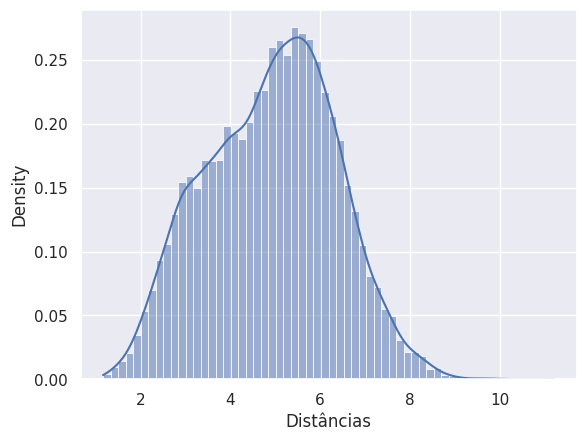

In [ ]:
distances = pdist(X_scaled, 'euclidean')
ax = sns.histplot(data = distances, stat = "density", kde = True);
ax.set(xlabel = 'Distâncias');

Após a padronização, as distâncias estão em um intervalo menor. Dessa forma, variações importantes em todas as características do conjunto de dados poderão impactar significativamente os valores das distâncias.

### Reescala

Na transformação por Reescala, o objetivo é transformar (**reescalar**) as características de um conjunto de dados de forma que cada uma assuma valores em um determinado intervalo.

Na ``scikit-learn``, uma forma de realizar a transformação por reescala é utilizando a classe [``MinMaxScaler``](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html#sklearn.preprocessing.MinMaxScaler).

Como no caso anterior, vamos exemplificar como isso pode ser feito utilizando o conjunto de dados ``wine``.

In [ ]:
from sklearn import preprocessing

# construindo o scaler para os dados
# feature_range: indica o intervalo para o qual os dados devem ser transformados
scaler = preprocessing.MinMaxScaler(feature_range = (0, 1))

# obtendo os parâmetros do scaler a partir do conjunto de dados
scaler.fit(X)

# transformando um conjunto de dados com o scaler obtido
X_scaled = scaler.transform(X)

# transformando os dados em pandas DataFrame
X_scaled = pd.DataFrame(X_scaled, index = X.index, columns = X.columns)
X_scaled

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,0.842105,0.191700,0.572193,0.257732,0.619565,0.627586,0.573840,0.283019,0.593060,0.372014,0.455285,0.970696,0.561341
1,0.571053,0.205534,0.417112,0.030928,0.326087,0.575862,0.510549,0.245283,0.274448,0.264505,0.463415,0.780220,0.550642
2,0.560526,0.320158,0.700535,0.412371,0.336957,0.627586,0.611814,0.320755,0.757098,0.375427,0.447154,0.695971,0.646933
3,0.878947,0.239130,0.609626,0.319588,0.467391,0.989655,0.664557,0.207547,0.558360,0.556314,0.308943,0.798535,0.857347
4,0.581579,0.365613,0.807487,0.536082,0.521739,0.627586,0.495781,0.490566,0.444795,0.259386,0.455285,0.608059,0.325963
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,0.705263,0.970356,0.582888,0.510309,0.271739,0.241379,0.056962,0.735849,0.205047,0.547782,0.130081,0.172161,0.329529
174,0.623684,0.626482,0.598930,0.639175,0.347826,0.282759,0.086498,0.566038,0.315457,0.513652,0.178862,0.106227,0.336662
175,0.589474,0.699605,0.481283,0.484536,0.543478,0.210345,0.073840,0.566038,0.296530,0.761092,0.089431,0.106227,0.397290
176,0.563158,0.365613,0.540107,0.484536,0.543478,0.231034,0.071730,0.754717,0.331230,0.684300,0.097561,0.128205,0.400856


As estatísticas descritivas dos dados transformados são dadas a seguir.

In [ ]:
X_scaled.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,0.518584,0.315484,0.538244,0.458502,0.323278,0.453487,0.356386,0.437460,0.372523,0.322363,0.388170,0.491460,0.334446
std,0.213639,0.220780,0.146708,0.172142,0.155244,0.215811,0.210730,0.234818,0.180555,0.197806,0.185831,0.260070,0.224613
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.350658,0.170455,0.454545,0.340206,0.195652,0.262931,0.182489,0.264151,0.264984,0.165529,0.245935,0.244505,0.158702
50%,0.531579,0.222332,0.534759,0.458763,0.304348,0.474138,0.378692,0.396226,0.361199,0.290956,0.394309,0.553114,0.282097
75%,0.696711,0.462945,0.640374,0.561856,0.402174,0.627586,0.534810,0.580189,0.485804,0.419795,0.520325,0.695971,0.504280
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


As distâncias dos dados transformados são dadas a seguir.

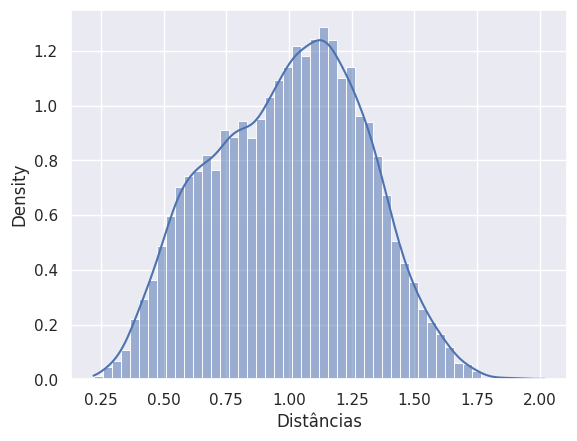

In [ ]:
distances = pdist(X_scaled, 'euclidean')
ax = sns.histplot(data = distances, stat = "density", kde = True);
ax.set(xlabel = 'Distâncias');

Assim como no caso da padronização, as distâncias estão em um intervalo menor. Dessa forma, variações importantes em todas as características do conjunto de dados poderão impactar significativamente os valores das distâncias.

# What is next?

Lista 2 =)